In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# set random seed 
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    
set_seed(42)

# checking if GPU exist mps is M seriers chips framework
if torch.backends.mps.is_available():
    device = torch.device('mps')  # for M serier
elif torch.cuda.is_available():
    device = torch.device('cuda')  # NVIDIA GPU
else:
    device = torch.device('cpu')   # CPU backup

print(f'Using device: {device}')

Using device: cuda


In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [4]:
print(f"#Train DataSet: {len(train_df)}")
print(f"#Test Dataset: {len(test_df)}")
print(f"\nLabel Distribution:")
print(train_df['label'].value_counts())
print(f"\nIn total: {train_df['label'].nunique()} categories leaves")
OUTPUT_SIZE = train_df['label'].nunique()

#Train DataSet: 18353
#Test Dataset: 8800

Label Distribution:
label
maclura_pomifera            353
ulmus_rubra                 235
prunus_virginiana           223
acer_rubrum                 217
broussonettia_papyrifera    214
                           ... 
cedrus_deodara               58
ailanthus_altissima          58
crataegus_crus-galli         54
evodia_daniellii             53
juniperus_virginiana         51
Name: count, Length: 176, dtype: int64

In total: 176 categories leaves


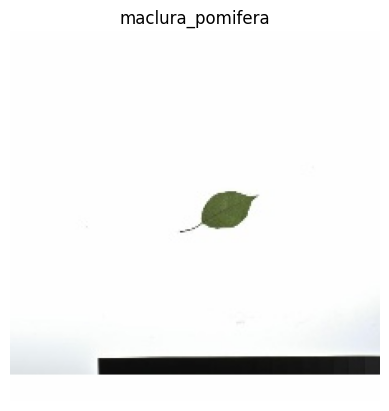

image size: (224, 224)


In [5]:
# check out the image sample 
sample_img = Image.open(f"data/{train_df.iloc[0]['image']}")
plt.imshow(sample_img)
plt.title(train_df.iloc[0]['label'])
plt.axis('off')
plt.show()
print(f"image size: {sample_img.size}")

In [6]:
# check image shape | channel
sample_img_array = np.array(sample_img)
print(f"img shape (height, width, channels): {sample_img_array.shape}")
print(f"# channels: {sample_img_array.shape[2]}")  

img shape (height, width, channels): (224, 224, 3)
# channels: 3


In [7]:
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])

print("Sample Header data:")
print(train_df[['image', 'label', 'label_encoded']].tail())

Sample Header data:
                  image                    label  label_encoded
18348  images/18348.jpg          aesculus_glabra             14
18349  images/18349.jpg  liquidambar_styraciflua             76
18350  images/18350.jpg            cedrus_libani             40
18351  images/18351.jpg      prunus_pensylvanica            125
18352  images/18352.jpg          quercus_montana            144


In [17]:
class SimpleLeafDataset(Dataset):
    """
    这个类就干三件事：
    1. 告诉PyTorch有多少张图片 (__len__)
    2. 告诉PyTorch怎么读第i张图片 (__getitem__)
    3. 把PIL图片转成Tensor
    """
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # 1. 读取图片
        img_path = f"data/{self.df.iloc[idx]['image']}"
        image = Image.open(img_path).convert('RGB')  # 确保是RGB 3通道
        
        # 2. 转成Tensor并归一化到[0,1]
        if self.transform:
            image = self.transform(image)
        else: 
            image = transforms.ToTensor()(image)  # 变成 (3, 224, 224)
        
        # 3. 拿到标签
        label = self.df.iloc[idx]['label_encoded']
        
        return image, label

# split train data into valid | train set
train_data, val_data = train_test_split(
    train_df, 
    test_size=0.1, 
    random_state=42,
    stratify=train_df['label']  # 保持类别分布一致
)

# train data reinforce 
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),      # 50% 概率水平翻转
    transforms.RandomVerticalFlip(p=0.5),        # 50% 概率垂直翻转
    transforms.RandomRotation(degrees=30),       # 随机旋转 ±30度
    transforms.ColorJitter(brightness=0.2,       # 亮度变化 ±20%
                          contrast=0.2,          # 对比度变化 ±20%
                          saturation=0.2),       # 饱和度变化 ±20%
    transforms.ToTensor()                        # 转为 Tensor，范围 [0, 1]
])

# train_dataset = SimpleLeafDataset(train_data)
train_dataset = SimpleLeafDataset(train_data, transform=train_transform)
val_dataset =  SimpleLeafDataset(val_data)
# 测试一下
img_test, label_test = train_dataset[0]
print(f"Image tensor shape: {img_test.shape}")  # 应该是 (3, 224, 224)
print(f"label: {label_test}")

Image tensor shape: torch.Size([3, 224, 224])
label: 173


In [20]:
# set up batch number
BATCH_SIZE = 12

# this is align in use with any class that inherit form Dataset, as long as you implement __len__ , __getitem__
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# test
for images, labels in train_loader:
    print(f"image shape at one batch: {images.shape}")  # (BATCH_SIZE, 3, 224, 224)
    print(f"label shape at one batch: {labels.shape}")  # (BATCH_SIZE,)
    break  # [for] will automattically loop through dataset by [batch] we break at first loop in order to check

image shape at one batch: torch.Size([12, 3, 224, 224])
label shape at one batch: torch.Size([12])


In [21]:
# 加载预训练的ResNet18
model = models.resnet50(weights='DEFAULT')

# checkout whats in the last layer
print("fc layer in resnet18:", model.fc)
# 输出: Linear(in_features=512, out_features=1000, bias=True)
# 1000是ImageNet的类别数

# out output is 176
model.fc = nn.Linear(2048, 176)  # 512是ResNet18的特征维度，176是树叶类别数

print("fc layer after modified:", model.fc)

# 把模型移到设备上（CPU或GPU）
model = model.to(device)


## ------------ In case you want to modify any layer? --------------------
# ResNet(
#   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
#   (bn1): BatchNorm2d(64)
#   (relu): ReLU(inplace=True)
#   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1)
  
#   (layer1): Sequential(
#     (0): BasicBlock(
#       (conv1): Conv2d(64, 64, kernel_size=(3, 3), padding=(1, 1))
#       (bn1): BatchNorm2d(64)
#       (relu): ReLU(inplace=True)
#       (conv2): Conv2d(64, 64, kernel_size=(3, 3), padding=(1, 1))
#       (bn2): BatchNorm2d(64)
#     )
#     (1): BasicBlock(...)
#   )
  
#   (layer2): Sequential(...)  # 更多层
#   (layer3): Sequential(...)
#   (layer4): Sequential(...)
  
#   (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
#   (fc): Linear(in_features=512, out_features=1000)  # ← 最后一层
# )

fc layer in resnet18: Linear(in_features=2048, out_features=1000, bias=True)
fc layer after modified: Linear(in_features=2048, out_features=176, bias=True)


In [22]:
# 损失函数：交叉熵（多分类标准做法）
criterion = nn.CrossEntropyLoss()

# 优化器：Adam（简单好用）
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [24]:
# 训练一个epoch

num_epochs = 12
best_val_acc = 0

for epoch in range(num_epochs):
    print(f'\n{"="*50}')
    print(f'Epoch {epoch+1}/{num_epochs}')
    print("="*50)

    # ====== training stage ======
    model.train()  
    train_loss = 0
    train_correct = 0
    train_total = 0
    

    #tqdm is a visuallized processbar so we could see the process

    for images, labels in tqdm(train_loader, desc='Training'):
        # 1. 数据移到设备上
        images = images.to(device)
        labels = labels.to(device).long()
    
        # 2. 前向传播
        outputs = model(images)  # (32, 176) - 每张图片对176个类别的预测分数
    
        # 3. 计算损失
        loss = criterion(outputs, labels)
    
        # 4. 反向传播
        optimizer.zero_grad()  # 清空之前的梯度
        loss.backward()        # 计算梯度
        optimizer.step()       # 更新权重
    
        # 5. 统计准确率
        _, predicted = outputs.max(1)  # 找到分数最高的类别
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
        train_loss += loss.item()

    train_avg_loss = train_loss / len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    
    # ====== valid stage ======
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device).long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * val_correct / val_total
    avg_val_loss = val_loss / len(valid_loader)

    # 打印结果
    print(f'\nLoss: {train_avg_loss:.4f}, Accuracy: {train_accuracy:.2f}%')
    print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_step0.pth')
        print(f'✓ 保存最佳模型! Val Acc: {val_acc:.2f}%')
        
print(f'\n {num_epochs} epochs done！')


Epoch 1/12


Validating: 100%|████████████████████████████████████████████████████████████████████| 153/153 [00:20<00:00,  7.49it/s]



Loss: 0.5579, Accuracy: 81.49%
Val Loss: 0.8166, Val Acc: 73.97%
✓ 保存最佳模型! Val Acc: 73.97%

Epoch 2/12


Validating: 100%|████████████████████████████████████████████████████████████████████| 153/153 [00:04<00:00, 34.78it/s]



Loss: 0.4803, Accuracy: 84.22%
Val Loss: 0.6782, Val Acc: 79.25%
✓ 保存最佳模型! Val Acc: 79.25%

Epoch 3/12


...


Loss: 0.2246, Accuracy: 92.07%
Val Loss: 0.3802, Val Acc: 87.36%

Epoch 11/12


Validating: 100%|████████████████████████████████████████████████████████████████████| 153/153 [00:04<00:00, 35.18it/s]



Loss: 0.2096, Accuracy: 92.62%
Val Loss: 0.3112, Val Acc: 90.09%
✓ 保存最佳模型! Val Acc: 90.09%

Epoch 12/12


Validating: 100%|████████████████████████████████████████████████████████████████████| 153/153 [00:04<00:00, 35.26it/s]


Loss: 0.1967, Accuracy: 93.22%
Val Loss: 0.6615, Val Acc: 79.90%

 12 epochs done！


In [25]:
# 创建测试集的Dataset和DataLoader
model.load_state_dict(torch.load('best_model_step0.pth'))
class TestDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = f"data/{self.df.iloc[idx]['image']}"
        image = Image.open(img_path).convert('RGB')
        image = transforms.ToTensor()(image)
        return image

test_dataset = TestDataset(test_df)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 预测
model.eval()  # 设置为评估模式
predictions = []

with torch.no_grad():  # 不计算梯度，节省内存
    for images in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1) # max(1) is select the most likely possibility label | _, predicted (value, index)
        predictions.extend(predicted.cpu().numpy()) # move data from GPU -> CPU and then convert to numpy

# 转回文字标签
predicted_labels = label_encoder.inverse_transform(predictions)

# 生成提交文件
submission = pd.DataFrame({
    'image': test_df['image'],
    'label': predicted_labels
})

submission.to_csv('submission.csv', index=False)
print('✓ 提交文件已生成!')
print(submission.head())

Predicting: 100%|████████████████████████████████████████████████████████████████████| 734/734 [01:42<00:00,  7.13it/s]

✓ 提交文件已生成!
              image                label
0  images/18353.jpg      asimina_triloba
1  images/18354.jpg         betula_nigra
2  images/18355.jpg  platanus_acerifolia
3  images/18356.jpg       pinus_bungeana
4  images/18357.jpg  platanus_acerifolia


In [ ]:
# steps note
# 0. baseline 5 epochs |  85.02% val acc
# 1. reinforcement of training data | 90% val acc